##使用等权z_score进行composite factor回测

Loading data...
Refined Universe: 394 stocks.
Calculating Composite Factors...


Processing Stocks: 100%|█████████████████████████████████████████████████████████████| 394/394 [21:51<00:00,  3.33s/it]


Executing daily selection...
Starting backtest loop...

--- Performance Metrics (Composite Z-Score) ---
Annualized Return: 0.1396
Volatility: 0.1550
Sharpe Ratio: 0.9003
Max Drawdown: -0.1433


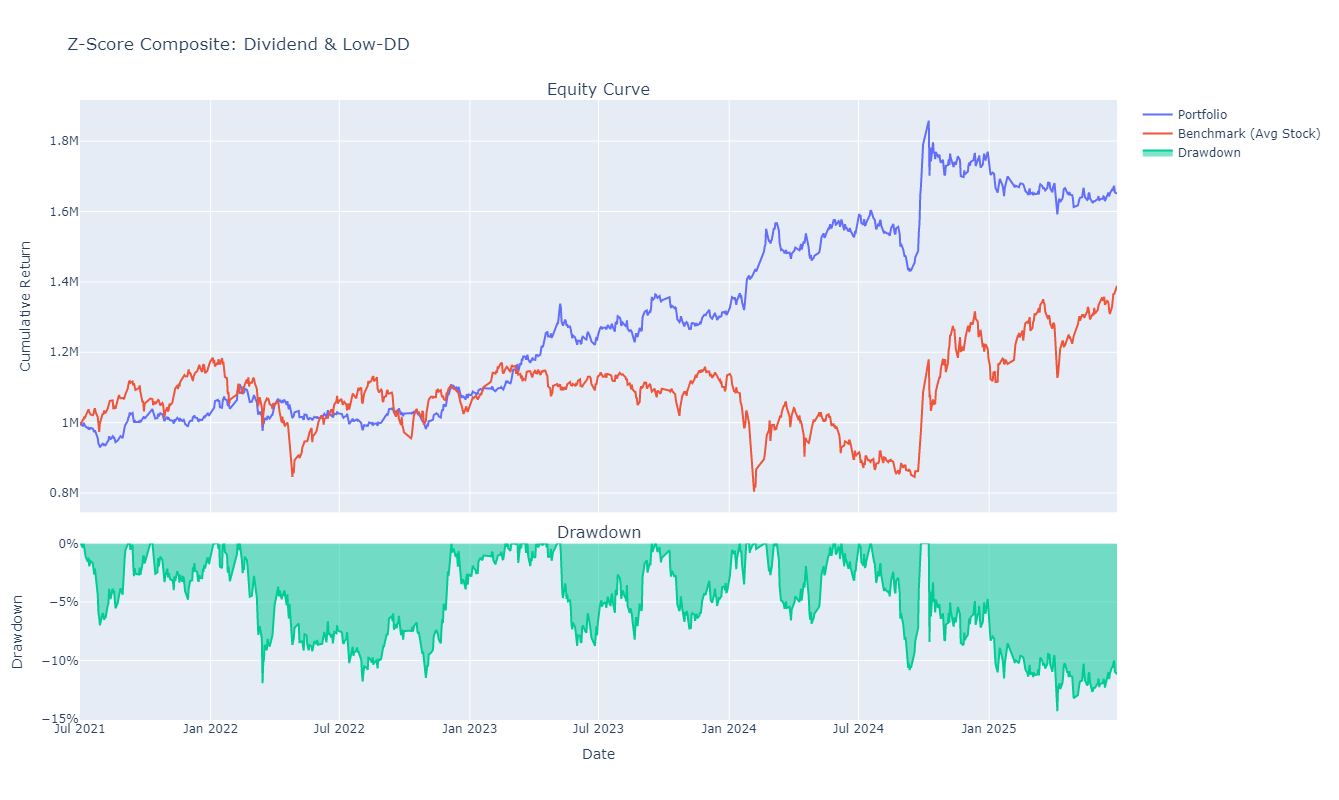

In [7]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from datetime import datetime, timedelta
from warnings import filterwarnings
from tqdm import tqdm

# 假设 util 模块保持不变
from util import (calc_factors, load_and_preprocess_price, load_selection,
                  get_top_n_selection, compute_benchmark_returns,
                  compute_metrics, plot_results)

filterwarnings('ignore')

# ----------------------------
# 0. 用户配置参数
# ----------------------------
stock_num = 5               # 每个行业选5只
INITIAL_CASH = 1_000_000
START_DATE = '2020-01-01'
END_DATE   = '2025-06-30'
REBALANCE_FREQ = 5          
TOP_N = 10                  
HALFLIFE = 21               
RF_ANNUAL = 0.03 / 252      

PRICE_FILE = 'eod_prices.parquet'
DIVIDEND_FILE = 'dividend.parquet'
FUND_FILE = 'ETF_hold_510300.SH.parquet'
INDUSTRY_FILE = 'Stock_Industry_Year.parquet'

# ----------------------------
# 1. 核心计算函数
# ----------------------------
def ewma_alpha(halflives):
    return 1 - np.exp(-np.log(2) / halflives)

def calc_inv_log_dd_factor(series, halflives, rf):
    returns = np.log(series / series.shift(1)) - rf
    r_neg = returns.where(returns <= 0, 0)
    r_neg_var = r_neg**2
    alpha = ewma_alpha(halflives)
    dd = np.sqrt(r_neg_var.ewm(alpha=alpha).mean())
    return 1.0 / np.log(dd + 1e-10)

# ----------------------------
# 2. 数据加载与预处理 (彻底解决 Category 与 5693 标的问题)
# ----------------------------
print("Loading data...")
dividend = pd.read_parquet(DIVIDEND_FILE)
price_dt = pd.read_parquet(PRICE_FILE)
fund_df = pd.read_parquet(FUND_FILE)
industry_df = pd.read_parquet(INDUSTRY_FILE)

# 暴力转换日期格式
price_dt['trade_date'] = pd.to_datetime(price_dt['trade_date'])
dividend['announce_date'] = pd.to_datetime(dividend['announce_date'])
dividend['ex_date'] = pd.to_datetime(dividend['ex_date'])

# 处理成分股范围
fund_df['report_end_date'] = pd.to_datetime(fund_df['end_date'] if 'end_date' in fund_df.columns else fund_df['report_end_date'])
def get_position_valid_period(row):
    year = int(row['report_year'])
    if row['report_type'] == '中报':
        return pd.Series([pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-06-30')], index=['pos_start_date', 'pos_end_date'])
    elif row['report_type'] == '年报':
        return pd.Series([pd.to_datetime(f'{year}-07-01'), pd.to_datetime(f'{year}-12-31')], index=['pos_start_date', 'pos_end_date'])
    return pd.Series([row['report_end_date'], row['report_end_date']], index=['pos_start_date', 'pos_end_date'])

fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_position_valid_period, axis=1)
fund_holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()

# 【严格过滤股票池】锁定回测期内出现过的标的
mask_in_period = (fund_holdings['pos_end_date'] >= START_DATE) & (fund_holdings['pos_start_date'] <= END_DATE)
csi_300_universe = fund_holdings.loc[mask_in_period, 'stock_code'].unique()

# 这一步非常关键：去除 Categorical 类型的冗余 categories，否则 groupby 依然会按全量跑
price_dt_subset = price_dt[price_dt['stock_code'].isin(csi_300_universe)].copy()
if isinstance(price_dt_subset['stock_code'].dtype, pd.CategoricalDtype):
    price_dt_subset['stock_code'] = price_dt_subset['stock_code'].cat.remove_unused_categories()

dividend_subset = dividend[dividend['stock_code'].isin(csi_300_universe)].copy()
if isinstance(dividend_subset['stock_code'].dtype, pd.CategoricalDtype):
    dividend_subset['stock_code'] = dividend_subset['stock_code'].cat.remove_unused_categories()

print(f"Refined Universe: {len(csi_300_universe)} stocks.")

# ----------------------------
# 3. 复合因子计算
# ----------------------------
print("Calculating Composite Factors...")
df_factors_list = []

for stock, price_sub in tqdm(price_dt_subset.groupby('stock_code'), desc="Processing Stocks"):
    # 确保价格数据日期是 datetime
    price_sub = price_sub.sort_values('trade_date')
    price_sub['trade_date'] = price_sub['trade_date'].astype('datetime64[ns]')
    
    # A. 红利因子
    div_sub = dividend_subset[dividend_subset['stock_code'] == stock]
    if not div_sub.empty:
        factor_sub = calc_factors(price_sub, div_sub)
    else:
        factor_sub = price_sub[['stock_code', 'trade_date']].copy()
        factor_sub['dynamic_div_yield'] = 0.0
    
    # 强制将结果日期转为 datetime64[ns]，彻底杜绝 Category
    factor_sub['trade_date'] = factor_sub['trade_date'].astype('datetime64[ns]')
    
    # B. 下行偏差因子
    full_price_series = price_sub.set_index('trade_date')['adjusted_close']
    dd_f = calc_inv_log_dd_factor(full_price_series, HALFLIFE, RF_ANNUAL)
    # 确保 Series 的 Index 也是 datetime
    dd_f.index = dd_f.index.astype('datetime64[ns]')
    
    # C. 合并
    factor_sub = factor_sub.merge(
        dd_f.rename('dd_factor'), 
        left_on='trade_date', 
        right_index=True, 
        how='left'
    )
    df_factors_list.append(factor_sub)

factor_dt = pd.concat(df_factors_list, ignore_index=True)
factor_dt['year'] = factor_dt['trade_date'].dt.year
industry_df['year'] = industry_df['year'].astype(int)
factor_dt = factor_dt.merge(industry_df[['stock_code', 'year', 'industry_name']], on=['stock_code', 'year'], how='left')

# ----------------------------
# 4. 复合选股逻辑 (Z-Score)
# ----------------------------
def select_composite_stocks(date_group):
    trade_date = date_group.name
    daily_data = date_group.copy().dropna(subset=['dynamic_div_yield', 'dd_factor', 'industry_name'])
    
    valid_list = fund_holdings[
        (fund_holdings['pos_start_date'] <= trade_date) & 
        (fund_holdings['pos_end_date'] >= trade_date)
    ]['stock_code'].tolist()
    
    holding_stocks = daily_data[daily_data['stock_code'].isin(valid_list)]
    if len(holding_stocks) == 0: return pd.DataFrame()

    holding_stocks['div_w'] = winsorize(holding_stocks['dynamic_div_yield'].values, limits=(0.01, 0.01))
    holding_stocks['dd_w'] = winsorize(holding_stocks['dd_factor'].values, limits=(0.01, 0.01))
    
    zscore = lambda s: (s - s.mean()) / (s.std() + 1e-10)
    holding_stocks['z_div'] = zscore(holding_stocks['div_w'])
    holding_stocks['z_dd'] = zscore(holding_stocks['dd_w'])
    
    holding_stocks['composite_score'] = (holding_stocks['z_div'] + holding_stocks['z_dd']) / 2.0
    
    selected = holding_stocks.groupby('industry_name', group_keys=False).apply(
        lambda x: x.sort_values('composite_score', ascending=False).head(stock_num)
    )
    selected = selected.sort_values('composite_score', ascending=False)
    selected['selection_rank'] = range(1, len(selected)+1)
    return selected

print("Executing daily selection...")
final_selection_df = factor_dt.groupby('trade_date', group_keys=False).apply(select_composite_stocks).reset_index(drop=True)

# ----------------------------
# 5. 回测逻辑
# ----------------------------
print("Starting backtest loop...")
price_pivot = price_dt.pivot(index='trade_date', columns='stock_code', values='adjusted_close').sort_index()
price_pivot.index = pd.to_datetime(price_pivot.index)
price_pivot = price_pivot.loc[START_DATE:END_DATE]

selection_df = final_selection_df[(final_selection_df['trade_date'] >= START_DATE) & (final_selection_df['trade_date'] <= END_DATE)]
rebalance_dates = sorted(selection_df['trade_date'].unique())[::REBALANCE_FREQ]
timeline = [d for d in price_pivot.index if d >= rebalance_dates[0]]

cash, holdings, portfolio_values = INITIAL_CASH, {}, []
benchmark_daily, benchmark_cum = compute_benchmark_returns(price_pivot, START_DATE, END_DATE)

for date in timeline:
    today_prices = price_pivot.loc[date]
    if date in rebalance_dates:
        for stock, shares in holdings.items():
            p = today_prices.get(stock, np.nan)
            if pd.notna(p): cash += shares * p
        holdings = {}
        selected = get_top_n_selection(selection_df, date, TOP_N)
        if selected:
            valid_stocks = [s for s in selected if pd.notna(today_prices.get(s, np.nan))]
            if valid_stocks:
                amt = cash / len(valid_stocks)
                for s in valid_stocks:
                    holdings[s] = amt / today_prices[s]
                cash = 0.0

    current_val = cash + sum(sh * today_prices.get(st, 0) for st, sh in holdings.items() if pd.notna(today_prices.get(st, 0)))
    portfolio_values.append(current_val)

# 评价结果
portfolio_series = pd.Series(portfolio_values, index=timeline, name='Portfolio')
benchmark_funds = INITIAL_CASH * (benchmark_cum.reindex(timeline, method='ffill') / benchmark_cum.loc[timeline[0]])
portfolio_returns = portfolio_series.pct_change().dropna()
metrics = compute_metrics(portfolio_returns, rf=0, periods_per_year=252)

print("\n--- Performance Metrics (Composite Z-Score) ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

plot_results(portfolio_series, benchmark_funds, timeline, title='Z-Score Composite: Dividend & Low-DD')